In [1]:
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image

import models_mae

In [52]:
# define the utils

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])


def show_image(image, title=""):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis("off")
    return


def prepare_model(chkpt_dir, arch="mae_vit_large_patch16"):
    # build model
    model = getattr(models_mae, arch)()
    # load model
    checkpoint = torch.load(chkpt_dir, map_location="cpu")
    msg = model.load_state_dict(checkpoint["model"], strict=False)
    print(msg)
    return model


def run_one_image(img, model, mask_ratio=0.75, show=True):
    x = torch.tensor(img)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum("nhwc->nchw", x)

    # run MAE
    latent, mask, ids_restore = model.forward_encoder(x.float(), mask_ratio)
    if not show:  # unshuffle the latent tokens
        cls = latent[:, 0, :]
        latent = torch.gather(
            latent[:, 1:, :],
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1, 1, latent.shape[2]),
        )
        latent = torch.cat([cls.unsqueeze(1), latent], dim=1)
        return latent

    if show:
        y = model.forward_decoder(latent, ids_restore)  # [N, L, p*p*3]
        loss = model.forward_loss(x.float(), y, mask)
        y = model.unpatchify(y)
        y = torch.einsum("nchw->nhwc", y).detach().cpu()

        # visualize the mask
        mask = mask.detach()
        mask = mask.unsqueeze(-1).repeat(
            1, 1, model.patch_embed.patch_size[0] ** 2 * 3
        )  # (N, H*W, p*p*3)
        mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
        mask = torch.einsum("nchw->nhwc", mask).detach().cpu()

        x = torch.einsum("nchw->nhwc", x)

        # masked image
        im_masked = x * (1 - mask)

        # MAE reconstruction pasted with visible patches
        im_paste = x * (1 - mask) + y * mask

        # make the plt figure larger
        plt.rcParams["figure.figsize"] = [24, 24]

        plt.subplot(1, 4, 1)
        show_image(x[0], "original")

        plt.subplot(1, 4, 2)
        show_image(im_masked[0], "masked")

        plt.subplot(1, 4, 3)
        show_image(y[0], "reconstruction")

        plt.subplot(1, 4, 4)
        show_image(im_paste[0], "reconstruction + visible")

        plt.show()

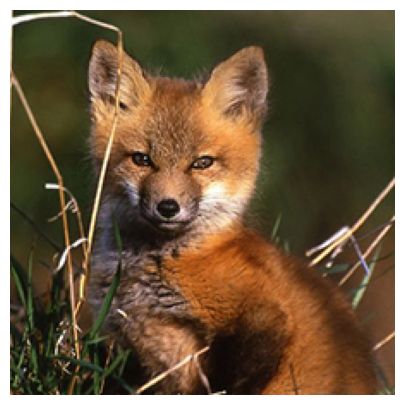

In [3]:
# load an image
img_url = "https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg"  # fox, from ILSVRC2012_val_00046145
# img_url = 'https://user-images.githubusercontent.com/11435359/147743081-0428eecf-89e5-4e07-8da5-a30fd73cc0ba.jpg' # cucumber, from ILSVRC2012_val_00047851
img = Image.open(requests.get(img_url, stream=True).raw)
img = img.resize((224, 224))
img = np.array(img) / 255.0

assert img.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img - imagenet_mean
img = img / imagenet_std

plt.rcParams["figure.figsize"] = [5, 5]
show_image(torch.tensor(img))

In [4]:
# This is an MAE model trained with pixels as targets for visualization (ViT-Large, training mask ratio=0.75)

# download checkpoint if not exist
!wget -nc https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large.pth

chkpt_dir = "mae_visualize_vit_large.pth"
model_mae = prepare_model(chkpt_dir, "mae_vit_large_patch16")
print("Model loaded.")

File ‘mae_visualize_vit_large.pth’ already there; not retrieving.

<All keys matched successfully>
Model loaded.


In [5]:
type(model_mae)

models_mae.MaskedAutoencoderViT

MAE with pixel reconstruction:
tensor([[ 82, 108,  20, 163, 128, 102, 140, 184,  67,  77,  41, 146,  70,  30,
         174, 133,   9, 129, 176, 122, 137,  61, 155, 191, 152,   7, 169,  96,
         156, 111, 125,  91,  98, 130, 160,  72,  31,  79,  97,  88, 114, 180,
         149,  17, 166, 185, 170,  28,  27,  39,  89, 168,  29, 195,  35,  85,
         112, 132,  18,  37, 100, 126, 186, 154, 194,  99,  68,  40,  54,   1,
          38, 181,  12,  78,  56, 115, 173, 151, 101, 141, 116,  81,   6,  90,
          24,  86,  22, 139,  21, 118, 113,   3,  26, 167,  55,  74,  65, 144,
         153, 175, 157,  47, 164,  34, 177,  11,  14,  49,  93, 162,  76, 171,
          48,  58,  10, 109,  75,  44, 150,   8,   0,  32,   5,  83,  25, 183,
           2,  62, 131,  73, 105,  66, 159, 193, 187, 136, 190, 134,  43, 182,
          15, 103,  16,  46,  42, 179,   4,  87,  84,  36, 121, 189, 143,  69,
          45, 135,  60,  50,  95, 119, 104,  53,  57,  94,  92, 106, 165, 172,
         192, 142,  3

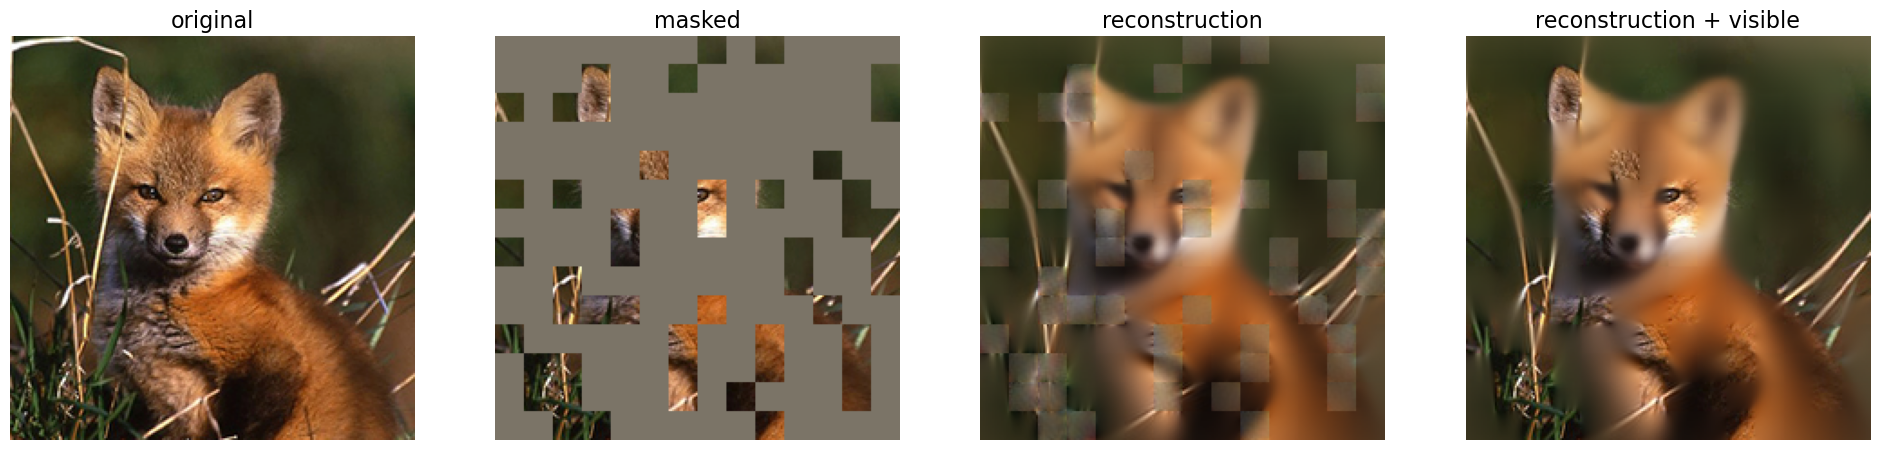

In [11]:
# make random mask reproducible (comment out to make it change)
torch.manual_seed(2)
print("MAE with pixel reconstruction:")
embs = run_one_image(img, model_mae)

MAE with pixel reconstruction:


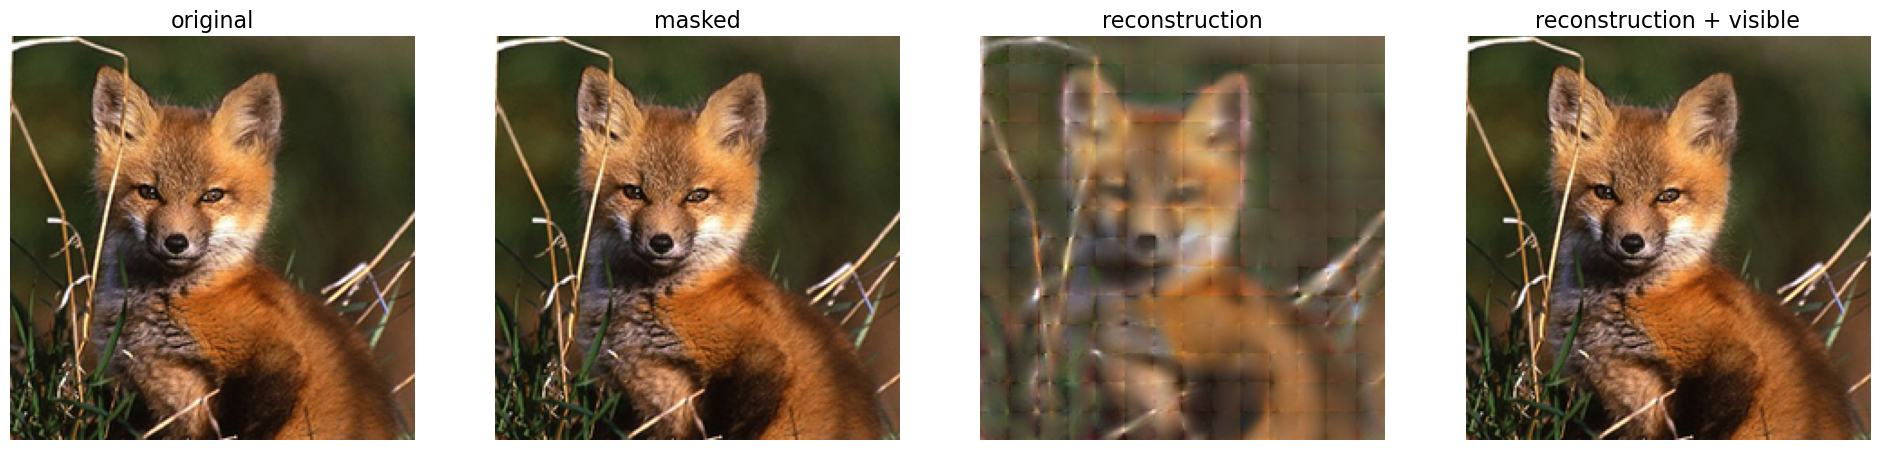

In [ ]:
# make random mask reproducible (comment out to make it change)
torch.manual_seed(2)
print("MAE with pixel reconstruction:")
embs = run_one_image(img, model_mae, 0.0)

In [53]:
embs1 = run_one_image(img, model_mae, 0.0, False)
embs2 = run_one_image(img, model_mae, 0.0, False)
embs1.shape, embs2.shape

tensor([[ 43,  57, 174,  35,  44,  63, 141,   6, 130, 147,  45, 187,  20,  18,
         123, 100,  98, 145,  67, 149, 110, 150, 159,  13, 195,  52, 126,  40,
         156,  95,  76, 128, 153, 166, 103, 151, 124,  30,  23,  11, 129, 172,
          78, 184, 158,  42, 109, 155,  32, 194, 104, 143,   0,  10,   3,  53,
          84,  37, 119,  87, 131, 157,  16, 133,  92,  34, 135,  38,  96,  41,
         139,  60,  17, 164, 191,  48, 171,  70, 117, 190,  27, 182, 178, 154,
          22,  36,  50,   5, 107,  47,  19, 181,  26,  69, 105,  15, 163, 175,
         173, 161, 115,  91, 112, 183,   1, 137,  82,  62, 101,   7,  85, 176,
          28, 189,  46,  89, 108,   4, 152,  29, 160, 122,  56,  73,  49,  51,
         111,  99, 121, 179,  24,  83,   8, 142,  31,  79, 114,  75,  25,  88,
          97,  86, 162,  81, 148, 169, 140, 106, 116, 146,  66, 132,  61, 193,
         186,  65, 144, 118,  80,  93,  94, 188, 138,  21,  72, 170,  71,  64,
         192,   2, 134, 120,  77, 168, 113, 167,  59

(torch.Size([1, 197, 1024]), torch.Size([1, 197, 1024]))

In [54]:
embs1[0, 0, :10], embs2[0, 0, :10]

(tensor([-0.0387,  0.2599,  0.0095,  0.2185, -0.0815, -0.0222, -0.2716,  0.1146,
         -0.0511,  0.1219], grad_fn=<SliceBackward0>),
 tensor([-0.0387,  0.2599,  0.0095,  0.2185, -0.0815, -0.0222, -0.2716,  0.1146,
         -0.0511,  0.1219], grad_fn=<SliceBackward0>))

In [55]:
embs1[0, 1, :10], embs2[0, 1, :10]

(tensor([-0.1643,  0.2963, -0.0115, -0.1356, -1.5975, -0.1757,  0.8405, -0.0357,
         -0.1326, -0.1049], grad_fn=<SliceBackward0>),
 tensor([-0.1643,  0.2963, -0.0115, -0.1356, -1.5975, -0.1757,  0.8405, -0.0357,
         -0.1326, -0.1049], grad_fn=<SliceBackward0>))

In [56]:
diff = embs1 - embs2
diff.min(), diff.max(), diff.mean(), diff.std()

(tensor(-5.7220e-06, grad_fn=<MinBackward1>),
 tensor(9.5367e-06, grad_fn=<MaxBackward1>),
 tensor(6.6420e-10, grad_fn=<MeanBackward0>),
 tensor(2.5687e-07, grad_fn=<StdBackward0>))

In [ ]:
N, L, D = 1, 3, 2
mask_ratio = 0.0

len_keep = int(L * (1 - mask_ratio))

noise = torch.rand(N, L)  # noise in [0, 1]

# sort noise for each sample
ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
print(ids_shuffle)
ids_restore = torch.argsort(ids_shuffle, dim=1)
print(ids_restore)
print(torch.gather(ids_shuffle, dim=1, index=ids_restore))
print()

tensor([[1, 2, 0]])
tensor([[2, 0, 1]])
tensor([[0, 1, 2]])



In [ ]:
latent = torch.tensor([[[1.0, 1.1], [2.0, 2.2], [3.0, 3.3]]])
print(latent)
print(latent.shape)
latent_shuffled = torch.gather(
    latent, dim=1, index=ids_shuffle.unsqueeze(-1).repeat(1, 1, latent.shape[2])
)
print(latent_shuffled)
latent_unshuffled = torch.gather(
    latent_shuffled,
    dim=1,
    index=ids_restore.unsqueeze(-1).repeat(1, 1, latent.shape[2]),
)
print(latent_unshuffled)

tensor([[[1.0000, 1.1000],
         [2.0000, 2.2000],
         [3.0000, 3.3000]]])
torch.Size([1, 3, 2])
tensor([[[2.0000, 2.2000],
         [3.0000, 3.3000],
         [1.0000, 1.1000]]])
tensor([[[1.0000, 1.1000],
         [2.0000, 2.2000],
         [3.0000, 3.3000]]])
